# Group 4 Data Analysis Project

In [121]:
library(tidyverse)
library(glmnet)
library(ucimlrepo)
library(scales)
library(pROC)
library(caret)

Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift




### Summary

`placeholder for summary`

### Introduction

`placeholder for introduction`

### Load Data

In [61]:
# Load data from internet
zip_url <- "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip"
temp <- tempfile()
download.file(zip_url, temp)
unzip(temp, files = "online_shoppers_intention.csv", exdir = tempdir())
csv_path <- file.path(tempdir(), "online_shoppers_intention.csv")
raw_shoppers_data <- read_csv(csv_path)

raw_shoppers_features <- raw_shoppers_data %>% select(-Revenue)
raw_shoppers_targets <- raw_shoppers_data %>% select(Revenue)

Rows: 12330 Columns: 18
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): Month, VisitorType
dbl (14): Administrative, Administrative_Duration, Informational, Informatio...
lgl  (2): Weekend, Revenue

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [62]:
head(raw_shoppers_features)
head(raw_shoppers_targets)

Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
0,0,0,0,1,0.000000,0.20000000,0.2000000,0,0,Feb,1,1,1,1,Returning_Visitor,FALSE
0,0,0,0,2,64.000000,0.00000000,0.1000000,0,0,Feb,2,2,1,2,Returning_Visitor,FALSE
0,0,0,0,1,0.000000,0.20000000,0.2000000,0,0,Feb,4,1,9,3,Returning_Visitor,FALSE
0,0,0,0,2,2.666667,0.05000000,0.1400000,0,0,Feb,3,2,2,4,Returning_Visitor,FALSE
0,0,0,0,10,627.500000,0.02000000,0.0500000,0,0,Feb,3,3,1,4,Returning_Visitor,TRUE
0,0,0,0,19,154.216667,0.01578947,0.0245614,0,0,Feb,2,2,1,3,Returning_Visitor,FALSE


Revenue
<lgl>
FALSE
FALSE
FALSE
FALSE
FALSE
FALSE


### EDA

We start with exploring the features in the data and its quantity

Table 1:
`insert table with all numerical features`
Table 2:
`insert table with all categorical features`

In [63]:
# Convert categorical features to factors + more cleaning
shoppers_features <- raw_shoppers_features %>% 
    mutate(
        Month = as.factor(Month),
        OperatingSystems = as.factor(OperatingSystems),
        Browser = as.factor(Browser),
        TrafficType = as.factor(TrafficType),
        VisitorType = as.factor(VisitorType),
        Weekend = as.factor(Weekend),
        Region = as.factor(Region)) %>%
    drop_na() %>% 
    droplevels()

shoppers_targets <- raw_shoppers_targets %>% 
    mutate(
        Revenue = ifelse(Revenue == "TRUE", "Yes", "No"),
        Revenue = as.factor(Revenue)) %>%
    drop_na() %>%
    droplevels()

cat("Figure 1: Overview of Online Shoppers Features Including Variable Types and Sample Values.\n")
str(shoppers_features)

Figure 1: Overview of Online Shoppers Features Including Variable Types and Sample Values.
tibble [12,330 × 17] (S3: tbl_df/tbl/data.frame)
 $ Administrative         : num [1:12330] 0 0 0 0 0 0 0 1 0 0 ...
 $ Administrative_Duration: num [1:12330] 0 0 0 0 0 0 0 0 0 0 ...
 $ Informational          : num [1:12330] 0 0 0 0 0 0 0 0 0 0 ...
 $ Informational_Duration : num [1:12330] 0 0 0 0 0 0 0 0 0 0 ...
 $ ProductRelated         : num [1:12330] 1 2 1 2 10 19 1 0 2 3 ...
 $ ProductRelated_Duration: num [1:12330] 0 64 0 2.67 627.5 ...
 $ BounceRates            : num [1:12330] 0.2 0 0.2 0.05 0.02 ...
 $ ExitRates              : num [1:12330] 0.2 0.1 0.2 0.14 0.05 ...
 $ PageValues             : num [1:12330] 0 0 0 0 0 0 0 0 0 0 ...
 $ SpecialDay             : num [1:12330] 0 0 0 0 0 0 0.4 0 0.8 0.4 ...
 $ Month                  : Factor w/ 10 levels "Aug","Dec","Feb",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ OperatingSystems       : Factor w/ 8 levels "1","2","3","4",..: 1 2 4 3 3 2 2 1 2 2 ...
 $ Brow

In [64]:
# Split train and test
set.seed(310)

split_ratio = 0.8
shoppers_size = nrow(shoppers_features)
train_idx <- sample(1:shoppers_size, split_ratio * shoppers_size)

shoppers_features_train <- shoppers_features[train_idx, ]
shoppers_features_test <- shoppers_features[-train_idx, ]

shoppers_targets_train <- shoppers_targets[train_idx, ]
shoppers_targets_test <- shoppers_targets[-train_idx, ]

shoppers_train <- bind_cols(shoppers_features_train, shoppers_targets_train)
shoppers_test <- bind_cols(shoppers_features_test, shoppers_targets_test)

In [65]:
# Get Summaries
summary_shoppers_features_train <- shoppers_features_train %>%
    select(where(is.numeric)) %>%
    summarise(
        across(
            everything(),
            list(
                n = ~sum(!is.na(.)),
                missing = ~sum(is.na(.)),
                mean = ~mean(., na.rm = TRUE),
                sd = ~sd(., na.rm = TRUE),
                min = ~min(., na.rm = TRUE),
                median = ~median(., na.rm = TRUE),
                max = ~max(., na.rm = TRUE)
            ),
            .names = "{.col}__{.fn}"
        )
    ) %>%
    pivot_longer(
        everything(),
        names_to = c("variable", "stat"),
        names_sep = "__",
        values_to = "value"
    ) %>%
    pivot_wider(names_from = stat, values_from = value) %>%
    arrange(variable) %>%
    mutate(
        across(
            c(mean, sd, min, median, max),
            ~round(., 3)
        )
    )

cat("Figure 2: Summary Statistics of Numerical Variables in Shoppers data\n")
summary_shoppers_features_train

Figure 2: Summary Statistics of Numerical Variables in Shoppers data


variable,n,missing,mean,sd,min,median,max
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Administrative,9864,0,2.327,3.335,0,1.000,27.000
Administrative_Duration,9864,0,81.441,179.200,0,8.000,3398.750
BounceRates,9864,0,0.022,0.048,0,0.003,0.200
ExitRates,9864,0,0.043,0.048,0,0.025,0.200
Informational,9864,0,0.509,1.282,0,0.000,24.000
Informational_Duration,9864,0,34.943,142.935,0,0.000,2549.375
PageValues,9864,0,5.857,18.180,0,0.000,361.764
ProductRelated,9864,0,31.889,44.135,0,18.000,705.000
ProductRelated_Duration,9864,0,1200.199,1935.239,0,607.778,63973.522


In [125]:
# Label imbalance 
shoppers_target_imbalance_train <- shoppers_targets_train %>% 
    count(Revenue, name = "n") %>% 
    mutate(prop = scales::percent(n / sum(n), accuracy = 0.1))

cat("Figure 3: Distribution of Revenue Outcomes.")
shoppers_target_imbalance_train

Figure 3: Distribution of Revenue Outcomes.

Revenue,n,prop
<fct>,<int>,<chr>
No,8331,84.5%
Yes,1533,15.5%


In [126]:
# Get sparse features
unique_counts_shoppers_train <- shoppers_features_train %>% 
    select(where(is.numeric)) %>%
    summarise(across(everything(), ~ length(unique(.))))

zero_counts_shoppers_train <- shoppers_features_train %>% 
    select(where(is.numeric)) %>%
    summarise(across(everything(), ~ sum(. == 0)))

cat("Figure 4: Unique Values for Numeric Features")
unique_counts_shoppers_train
cat("Figure 5: Zero counts for Numeric Features")
zero_counts_shoppers_train

Figure 4: Unique Values for Numeric Features

Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
27,2816,16,1061,290,7838,1606,3957,2184,6


Figure 5: Zero counts for Numeric Features

Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
4597,4707,7749,7936,30,592,4433,58,7661,8857


In [95]:
# Convert unique numerical features into categorical
num_to_cat_shoppers_train <- shoppers_train %>%
    mutate(
        Administrative = as.factor(Administrative),
        Informational = as.factor(Informational),
        SpecialDay = as.factor(SpecialDay)
    )

num_to_cat_shoppers_test <- shoppers_test %>%
    mutate(
        Administrative = as.factor(Administrative),
        Informational = as.factor(Informational),
        SpecialDay = as.factor(SpecialDay)
    )

In [127]:
# Categorical Features Distribution
cat("Figure 6: Distribution of Categorical Features\n")
cat("----------------Visitor Type----------------")
table(num_to_cat_shoppers_train$VisitorType)
cat("----------------Month----------------")
table(num_to_cat_shoppers_train$Month)
cat("----------------Operating Systems----------------")
table(num_to_cat_shoppers_train$OperatingSystems)
cat("----------------Browser----------------")
table(num_to_cat_shoppers_train$Browser)
cat("----------------Traffic Type----------------")
table(num_to_cat_shoppers_train$TrafficType)
cat("----------------Weekend----------------")
table(num_to_cat_shoppers_train$Weekend)
cat("----------------Administrative----------------")
table(num_to_cat_shoppers_train$Administrative)
cat("----------------Informational----------------")
table(num_to_cat_shoppers_train$Informational)
cat("----------------Special Day----------------")
table(num_to_cat_shoppers_train$SpecialDay)
cat("----------------Region----------------")
table(num_to_cat_shoppers_train$Region)

Figure 6: Distribution of Categorical Features
----------------Visitor Type----------------


      New_Visitor             Other Returning_Visitor 
             1345                65              8454 

----------------Month----------------


 Aug  Dec  Feb  Jul June  Mar  May  Nov  Oct  Sep 
 336 1387  158  341  228 1513 2689 2400  455  357 

----------------Operating Systems----------------

...


   0    1    2    3    4    5    6    7    8    9   10   11   12   13   14   24 
7749  836  582  294  190   81   62   30   12   13    6    1    5    1    1    1 

----------------Special Day----------------


   0  0.2  0.4  0.6  0.8    1 
8857  140  190  273  271  133 

----------------Region----------------


   1    2    3    4    5    6    7    8    9 
3820  894 1947  934  264  645  610  344  406 

In [96]:
# Bin the sparse categories 
cleaned_cat_shoppers_train <- num_to_cat_shoppers_train %>%
    filter(VisitorType != "Other") %>%
    mutate(
        OperatingSystems = fct_collapse(
            OperatingSystems, Other = c("4", "5", "6", "7", "8")
        ),
        Browser = fct_collapse(
            Browser, Other = c("3", "7", "9", "11", "12", "13")
        ),
        TrafficType = fct_collapse(
            TrafficType, Other = c("7", "9", "12", "14", "15", "16", "17", "18", "19")
        ), 
        Administrative = fct_collapse(
            Administrative, Other = c("11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "26", "27")
        ),
        Informational = fct_collapse(
            Informational, Other = c("5", "6", "7", "8", "9", "10", "11", "12", "13", "14", "24")
        )
    ) %>% 
    droplevels()

cleaned_cat_shoppers_test <- num_to_cat_shoppers_test %>%
    filter(VisitorType != "Other") %>%
    mutate(
        OperatingSystems = fct_collapse(
            OperatingSystems, Other = c("4", "5", "6", "7", "8")
        ),
        Browser = fct_collapse(
            Browser, Other = c("3", "7", "9", "11", "12", "13")
        ),
        TrafficType = fct_collapse(
            TrafficType, Other = c("7", "9", "12", "14", "15", "16", "17", "18", "19")
        ), 
        Administrative = fct_collapse(
            Administrative, Other = c("11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "26", "27")
        ),
        Informational = fct_collapse(
            Informational, Other = c("5", "6", "7", "8", "9", "10", "11", "12", "13", "14", "24")
        )
    ) %>% 
    droplevels()

Warning message:
“There were 2 warnings in `mutate()`.
The first warning was:
ℹ In argument: `Administrative = fct_collapse(...)`.
Caused by warning:
! Unknown levels in `f`: 21, 23, 26, 27
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.”


In [128]:
# Categorical Features Distribution
cat("Figure 7: Clean Distribution of Categorical Features\n")
cat("----------------Visitor Type----------------")
table(cleaned_cat_shoppers_train$VisitorType)
cat("----------------Month----------------")
table(cleaned_cat_shoppers_train$Month)
cat("----------------Operating Systems----------------")
table(cleaned_cat_shoppers_train$OperatingSystems)
cat("----------------Browser----------------")
table(cleaned_cat_shoppers_train$Browser)
cat("----------------Traffic Type----------------")
table(cleaned_cat_shoppers_train$TrafficType)
cat("----------------Weekend----------------")
table(cleaned_cat_shoppers_train$Weekend)
cat("----------------Administrative----------------")
table(cleaned_cat_shoppers_train$Administrative)
cat("----------------Informational----------------")
table(cleaned_cat_shoppers_train$Informational)
cat("----------------Special Day----------------")
table(cleaned_cat_shoppers_train$SpecialDay)
cat("----------------Region----------------")
table(cleaned_cat_shoppers_train$Region)

Figure 7: Clean Distribution of Categorical Features
----------------Visitor Type----------------


      New_Visitor Returning_Visitor 
             1345              8454 

----------------Month----------------


 Aug  Dec  Feb  Jul June  Mar  May  Nov  Oct  Sep 
 336 1339  158  341  228 1513 2689 2383  455  357 

----------------Operating Systems----------------

...


    0     1     2     3     4 Other 
 7688   834   581   294   189   213 

----------------Special Day----------------


   0  0.2  0.4  0.6  0.8    1 
8792  140  190  273  271  133 

----------------Region----------------


   1    2    3    4    5    6    7    8    9 
3816  891 1939  929  264  644  609  344  363 

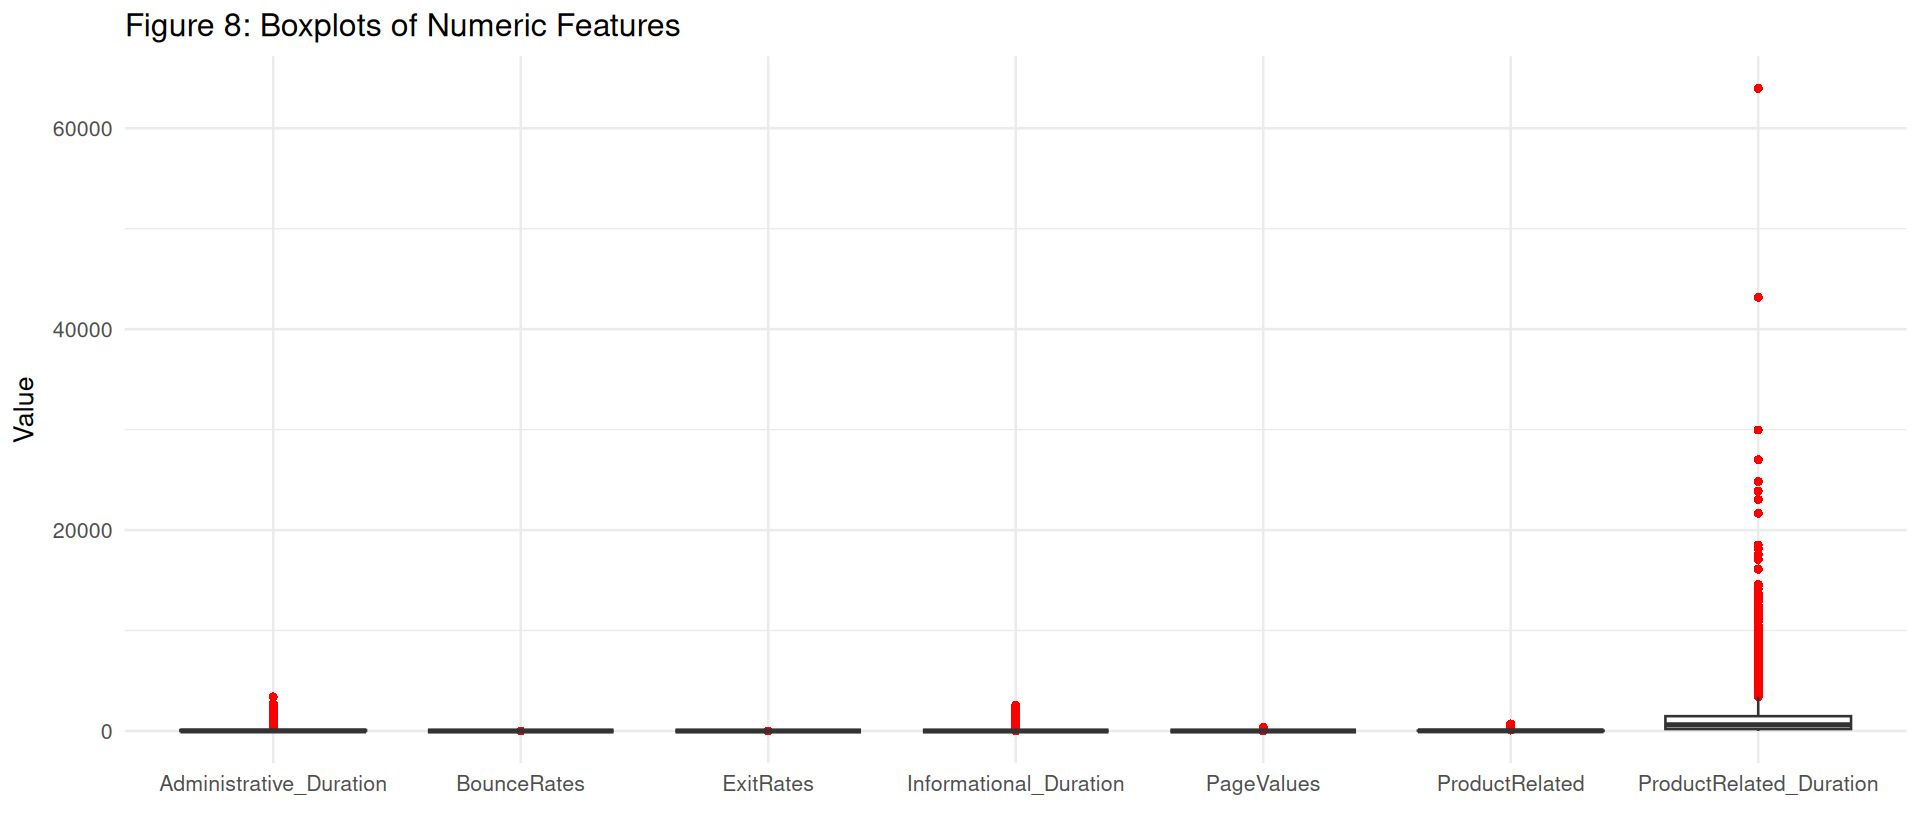

In [129]:
# Check Numerical Features
numeric_shoppers_train <- cleaned_cat_shoppers_train %>%
    select(where(is.numeric)) %>%
    pivot_longer(
        cols = everything(),
        names_to = "Variable",
        values_to = "Value"
    )

options(repr.plot.width = 16, repr.plot.height = 7)
ggplot(numeric_shoppers_train, aes(Variable, Value)) + 
    geom_boxplot(outlier.colour = "red", outlier.shape = 16) + 
    theme_minimal(base_size = 16) + 
    theme() +
    labs(
        title = "Figure 8: Boxplots of Numeric Features",
        y = "Value",
        x = ""
    )

In [98]:
# Fix numeric features
cleaned_shoppers_train <- cleaned_cat_shoppers_train %>%
    mutate(
        Administrative_Duration = log1p(Administrative_Duration),
        BounceRates = log1p(BounceRates),
        ExitRates = log1p(ExitRates),
        Informational_Duration = log1p(Informational_Duration),
        PageValues = log1p(PageValues),
        ProductRelated = log1p(ProductRelated),
        ProductRelated_Duration = log1p(ProductRelated_Duration)
    )

cleaned_shoppers_test <- cleaned_cat_shoppers_test %>%
    mutate(
        Administrative_Duration = log1p(Administrative_Duration),
        BounceRates = log1p(BounceRates),
        ExitRates = log1p(ExitRates),
        Informational_Duration = log1p(Informational_Duration),
        PageValues = log1p(PageValues),
        ProductRelated = log1p(ProductRelated),
        ProductRelated_Duration = log1p(ProductRelated_Duration)
    )

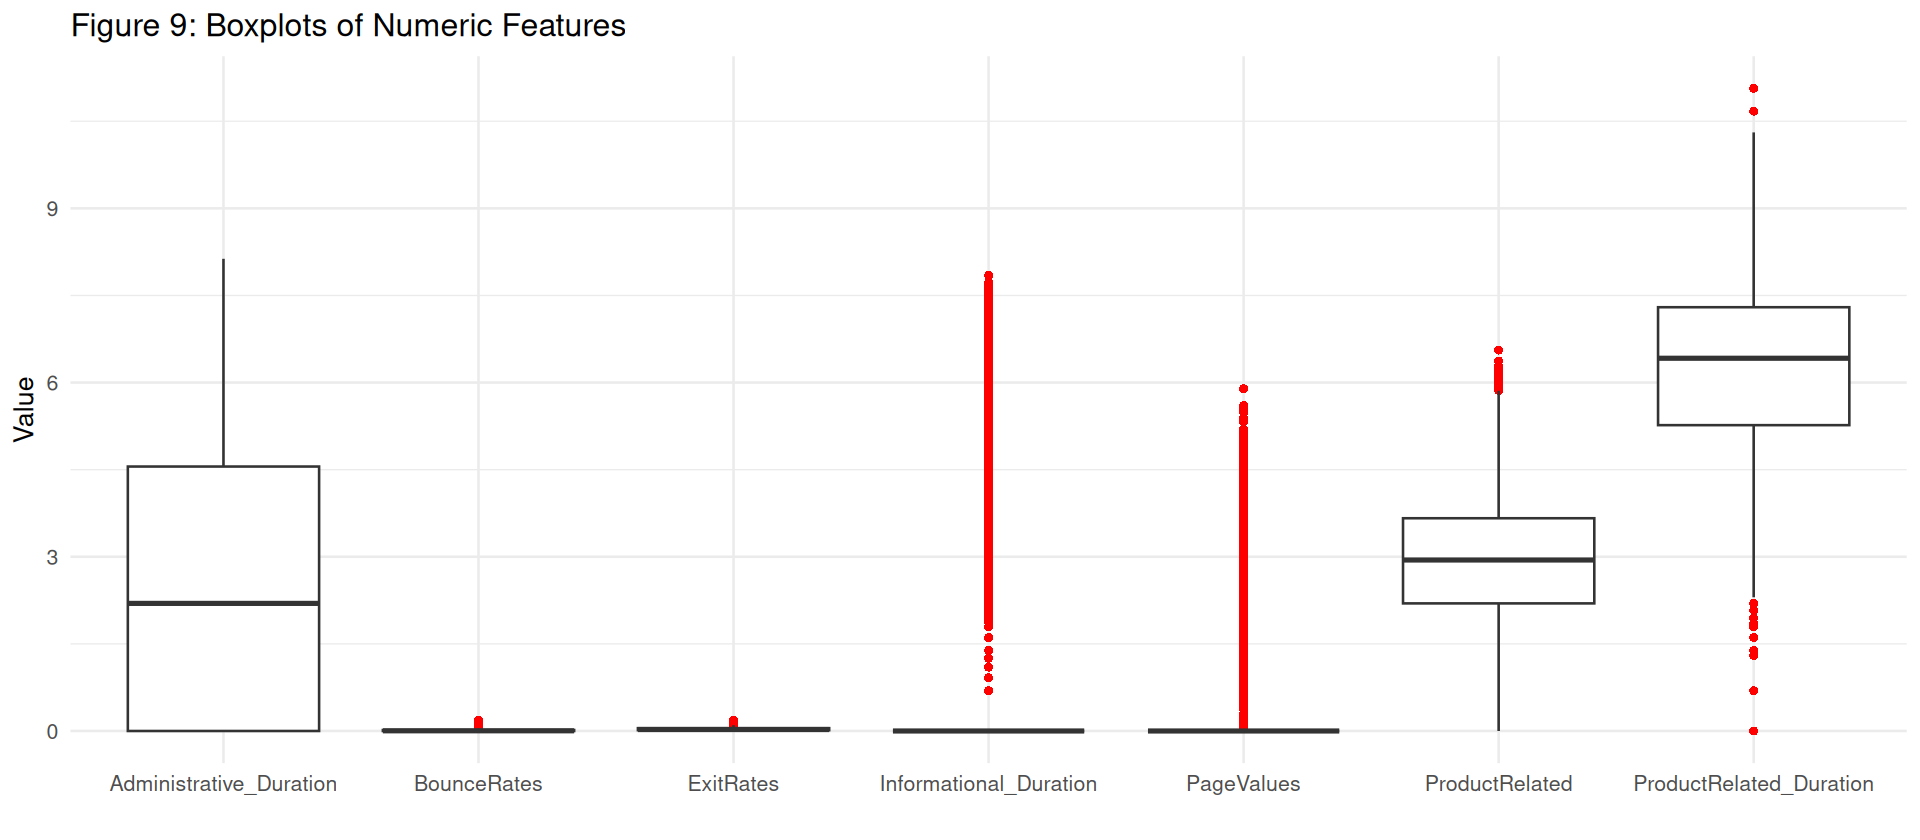

In [130]:
# Retry Numeric Visualization
cleaned_numeric_shoppers_train_long <- cleaned_shoppers_train %>%
    select(where(is.numeric)) %>%
    pivot_longer(
        cols = everything(),
        names_to = "Variable",
        values_to = "Value"
    )

ggplot(cleaned_numeric_shoppers_train_long, aes(Variable, Value)) + 
    geom_boxplot(outlier.colour = "red", outlier.shape = 16) + 
    theme_minimal(base_size = 16) + 
    theme() +
    labs(
        title = "Figure 9: Boxplots of Numeric Features",
        y = "Value",
        x = ""
    )

In [75]:
# Prepare Visualization Data
binned_purchase_rate_shoppers_train <- cleaned_shoppers_train %>%
    select(Weekend, Revenue, ProductRelated, ExitRates, SpecialDay) %>%
    mutate(
        Weekend = as.logical(Weekend),
        Revenue_num = if_else(Revenue == "Yes", 1, 0)
    )

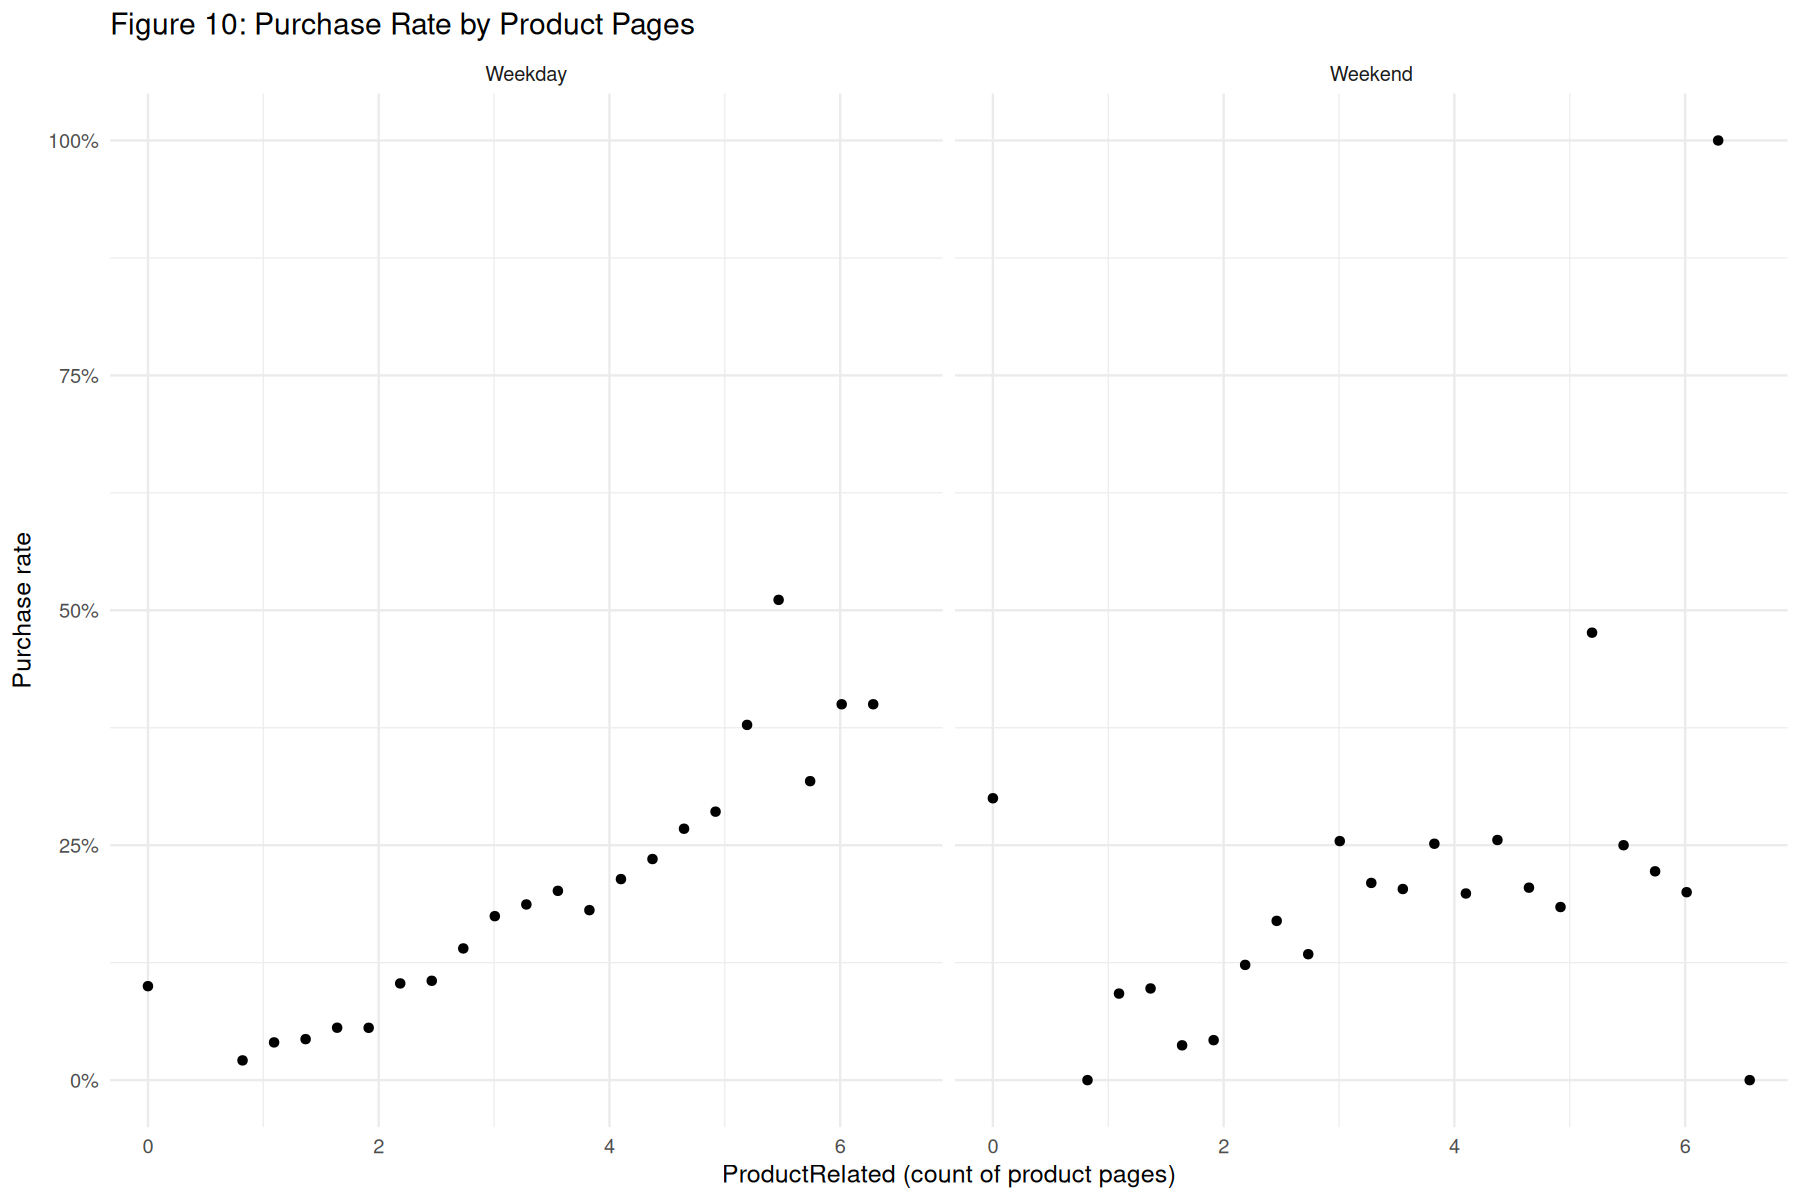

In [131]:
# Explore Purchase Rate by product pages
options(repr.plot.width = 15, repr.plot.height = 10)
ggplot(binned_purchase_rate_shoppers_train, aes(ProductRelated, Revenue_num)) + 
    stat_summary_bin(fun = mean, bins = 25, geom = "point") + 
    facet_wrap(~ Weekend, labeller = as_labeller(c(`FALSE`="Weekday", `TRUE`="Weekend"))) + 
    scale_y_continuous(labels = percent_format(accuracy = 1), limits = c(0, 1)) + 
    labs(title = "Figure 10: Purchase Rate by Product Pages",
         x = "ProductRelated (count of product pages)",
         y = "Purchase rate") +
    theme_minimal(base_size = 15)

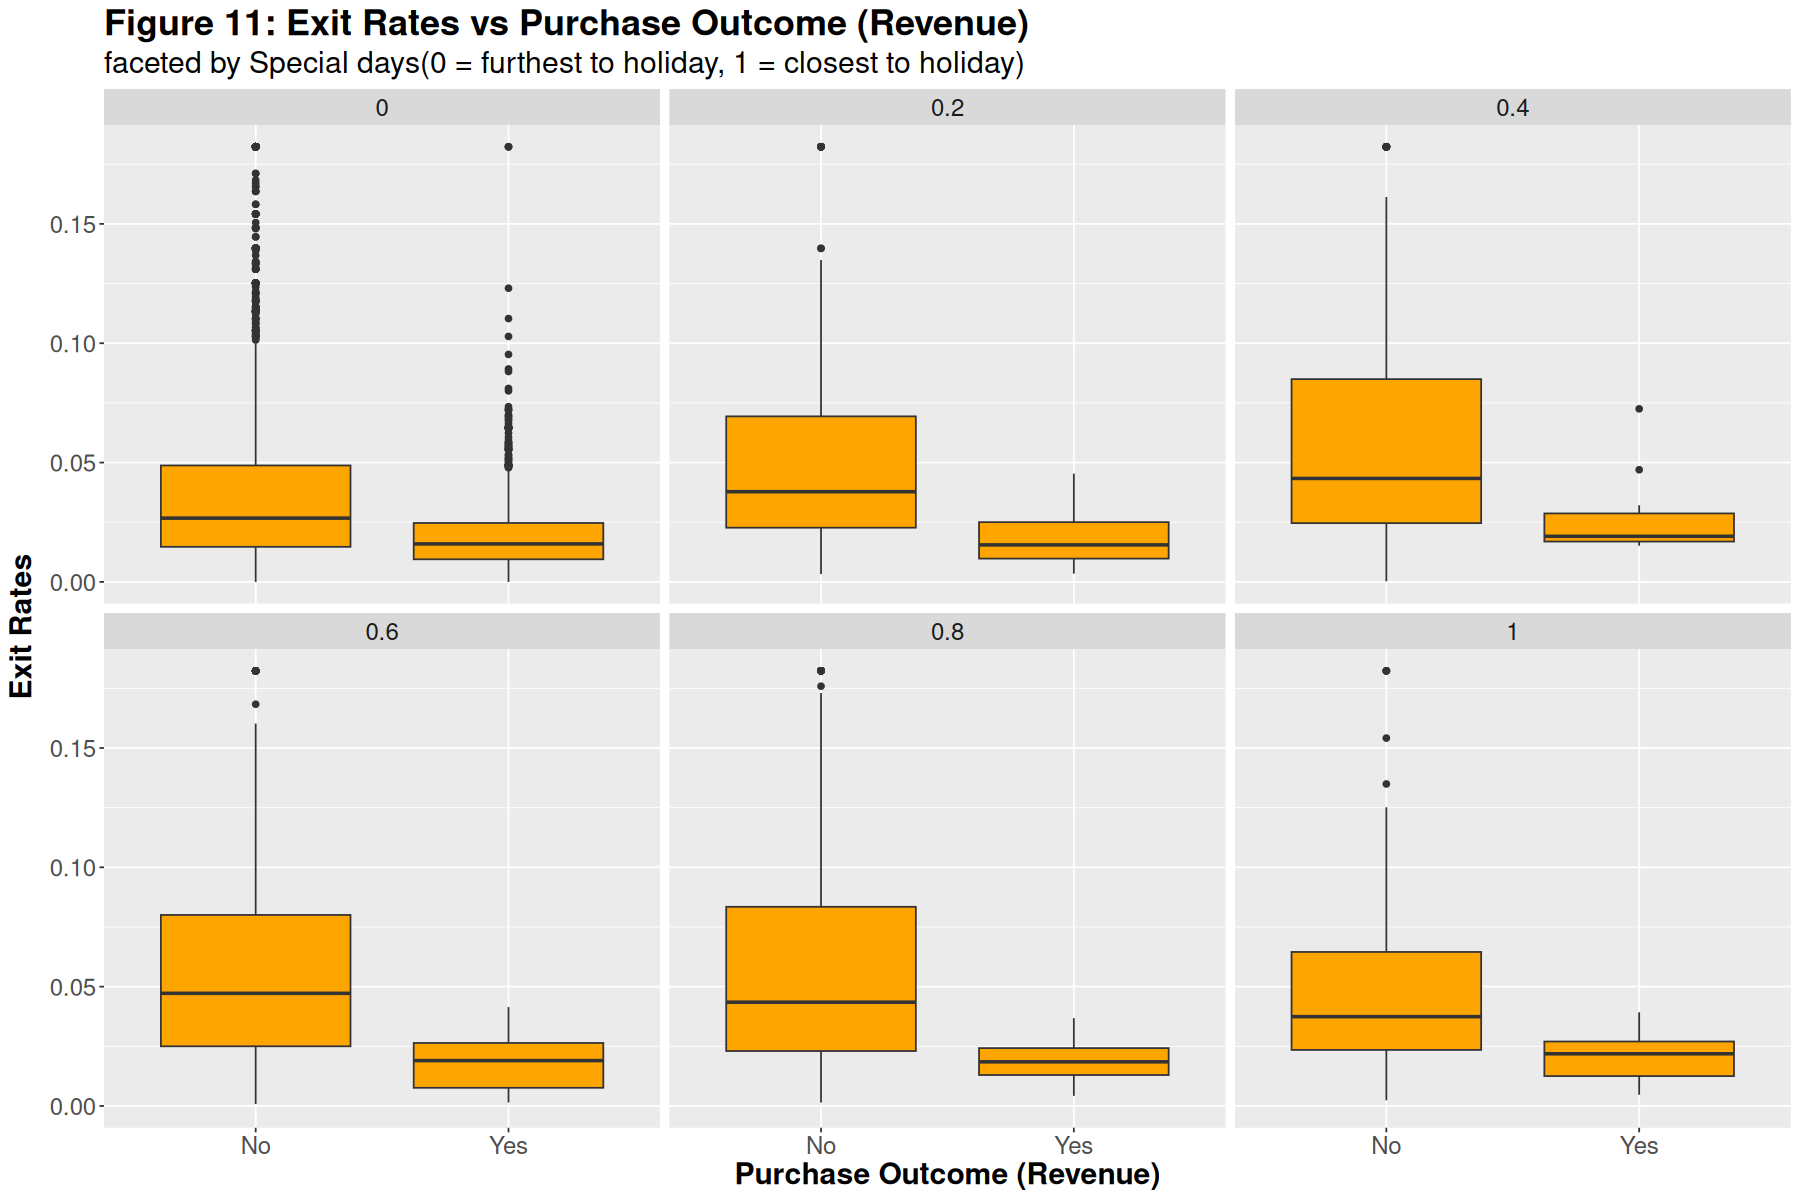

In [132]:
# Explore Exit Rates vs Purchase Outcome (Revenue)
ggplot(binned_purchase_rate_shoppers_train, aes(Revenue, ExitRates)) +
    geom_boxplot(fill = "orange") + 
    facet_wrap(~ SpecialDay) +
    labs(
        title = "Figure 11: Exit Rates vs Purchase Outcome (Revenue)",
        subtitle = "faceted by Special days(0 = furthest to holiday, 1 = closest to holiday)",
        x = "Purchase Outcome (Revenue)",
        y = "Exit Rates"
    ) + 
    theme(
        text = element_text(size = 18),
        plot.title = element_text(face = "bold"),
        axis.title = element_text(face = "bold")
    )

### Analysis

In [114]:
# Prepare Data
train_scaled <- cleaned_shoppers_train %>%
    mutate(across(where(is.numeric), scale))

test_scaled <- cleaned_shoppers_test %>%
    mutate(across(where(is.numeric), scale))

x_train <- train_scaled %>%
    select(-Revenue) %>%
    model.matrix(~ ., data = .) %>%
    .[, -1]
y_train <- as.numeric(train_scaled$Revenue)

x_test <- test_scaled %>%
    select(-Revenue) %>%
    model.matrix(~ ., data = .) %>%
    .[, -1]

zero_mat <- matrix(0, nrow = nrow(x_test), ncol = 1)
colnames(zero_mat) <- "Informational16"
x_test <- cbind(x_test, zero_mat)
x_test <- x_test[, colnames(x_train)]

y_test <- as.numeric(test_scaled$Revenue)

In [115]:
# Fit a LASSO Logistic Regression Model
cv_lasso <- cv.glmnet(x_train, y_train, family = "binomial", alpha = 1, type.measure = "auc")

cv_lasso_auc <- max(cv_lasso$cvm)
print(paste("Best Cross-Validation AUC:", cv_lasso_auc))

[1] "Best Cross-Validation AUC: 0.915112021306996"


In [123]:
# Get Results
final_lasso <- glmnet(x_train, y_train, family = "binomial", alpha = 1, lambda = cv_lasso$lambda.min)
lasso_test_pred <- predict(final_lasso, newx = x_test, s = "lambda.min", type = "response")

In [139]:
# Display Final Results
roc_lasso_test <- roc(cleaned_shoppers_test$Revenue, as.numeric(lasso_test_pred), levels = c("No", "Yes"), direction = "<")
lasso_test_auc <- auc(roc_lasso_test)
lasso_test_class <- factor(ifelse(as.numeric(lasso_test_pred) > 0.5, "Yes", "No"), levels = c("No", "Yes"))

cat("Figure 12:")
lasso_test_cm <- confusionMatrix(lasso_test_class, factor(cleaned_shoppers_test$Revenue, levels = c("No", "Yes")), positive = "Yes")
print(lasso_test_cm)

Figure 12:Confusion Matrix and Statistics

          Reference
Prediction   No  Yes
       No  1993  159
       Yes   84  210
                                          
               Accuracy : 0.9007          
                 95% CI : (0.8881, 0.9122)
    No Information Rate : 0.8491          
    P-Value [Acc > NIR] : 3.830e-14       
                                          
                  Kappa : 0.5769          
                                          
 Mcnemar's Test P-Value : 2.064e-06       
                                          
            Sensitivity : 0.56911         
            Specificity : 0.95956         
         Pos Pred Value : 0.71429         
         Neg Pred Value : 0.92612         
             Prevalence : 0.15086         
         Detection Rate : 0.08585         
   Detection Prevalence : 0.12020         
      Balanced Accuracy : 0.76433         
                                          
       'Positive' Class : Yes             
              

[1] "Figure 13: Test AUC for final Lasso model: 0.926"


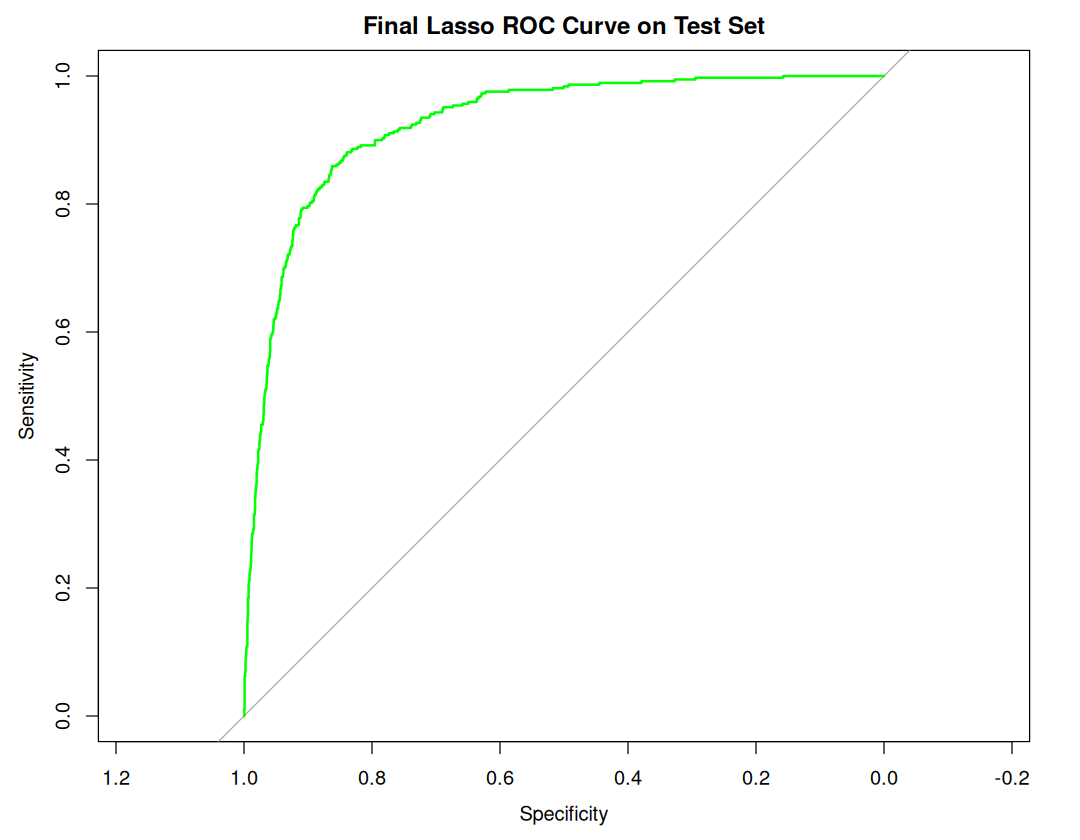

In [140]:
# Display Final ROC Curve
lasso_test_auc <- auc(roc_lasso_test)
print(paste("Figure 13: Test AUC for final Lasso model:", round(lasso_test_auc, 3)))

options(repr.plot.width = 9, repr.plot.height = 7)
plot(
    roc_lasso_test,
    col = "green",
    lwd = 2,
    main = "Final Lasso ROC Curve on Test Set"
)

### Discussion

`placeholder for discussion`

### References

`placeholder for references`